# Predicting Passenger Survival
## Using Classical Classifiers

**Problem**: Binary classification — predict whether a passenger survived (1) or not (0).

**Models used**: Logistic Regression, KNN, SVM, Decision Tree, Random Forest

---
## Section 1: Setup and Data Loading

In [7]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# We import all the libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

# Reproducibility and display settings
np.random.seed(42)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Get the folder where this notebook file is saved
notebook_dir = r"D:\College_Files\Skills\Github Repositories\Titanic Passenger Survival Prediction"

# Build the full path to passengers.csv
csv_path = os.path.join(notebook_dir, 'passengers.csv.csv')

# Load the dataset
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 12)


In [10]:
# Load dataset
df = pd.read_csv('passengers.csv.csv')
print('Dataset shape:', df.shape)
df.head(10)

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [11]:
df.info()
print("\n")
display(df.describe())
print('\n\nTarget class distribution\n')
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB




,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200




Target class distribution

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.62%
1    38.38%
Name: proportion, dtype: str


---
## Section 2: Exploratory Data Analysis (EDA)

Dataset size and class balance
**Answer**: The dataset contains **891 passengers**: ~342 survived (38.4%) and ~549 did not (61.6%). The dataset is **imbalanced** — non-survivors outnumber survivors roughly 3:2.

Dealing with Missing values!

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])
# Age: ~177 (19.9%), Cabin: ~687 (77.1%), Embarked: 2 (0.2%)

,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


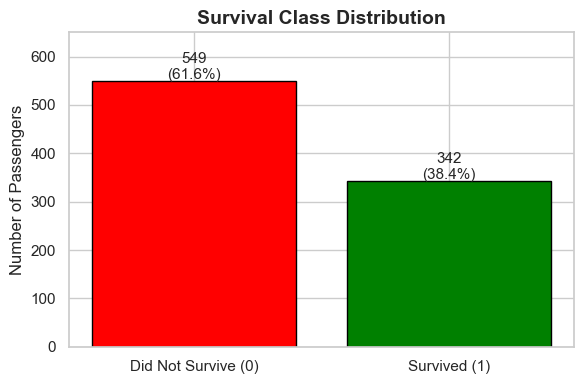

Survival rate: 38.4%


In [ ]:
# Class distribution bar plot
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Survived'].value_counts()
bars = ax.bar(['Did Not Survive (0)', 'Survived (1)'], counts.values,
              color=['red', 'green'], edgecolor='black')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Survival Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.show()
print(f'Survival rate: {df["Survived"].mean()*100:.1f}%')

Survival rate by gender (%):
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


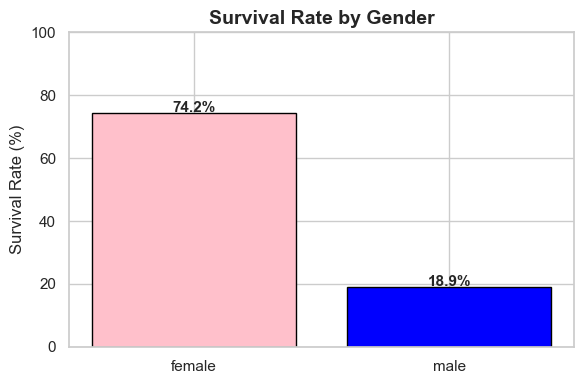

In [ ]:
# Survival by gender
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print('Survival rate by gender (%):')
print(survival_by_sex.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['pink', 'blue']
bars = ax.bar(survival_by_sex.index, survival_by_sex.values, color=colors, edgecolor='black')
for bar, val in zip(bars, survival_by_sex.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()
# Females had ~74% survival vs ~19% for males — a massive difference!

Survival rate by class (%):
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


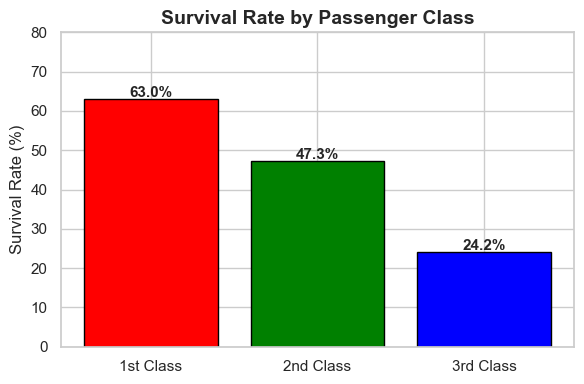

In [ ]:
# Survival by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print('Survival rate by class (%):')
print(survival_by_class.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
class_labels = ['1st Class', '2nd Class', '3rd Class']
bars = ax.bar(class_labels, survival_by_class.values,
              color=['red', 'green', 'blue'], edgecolor='black')
for bar, val in zip(bars, survival_by_class.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()
# 1st class ~63%, 2nd class ~47%, 3rd class ~24%

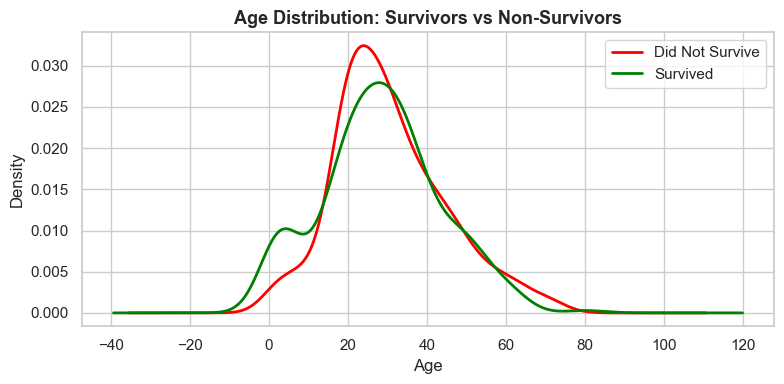

Mean age — Did not survive: 30.6
Mean age — Survived:        28.3


In [ ]:
# Age distribution by survival
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Survived'] == 0]['Age'].dropna().plot(kind='kde', ax=ax, color='red',
                                               label='Did Not Survive', linewidth=2)
df[df['Survived'] == 1]['Age'].dropna().plot(kind='kde', ax=ax, color='green',
                                              label='Survived', linewidth=2)
ax.set_title('Age Distribution: Survivors vs Non-Survivors', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print('Mean age — Did not survive:', df[df['Survived']==0]['Age'].mean().round(1))
print('Mean age — Survived:       ', df[df['Survived']==1]['Age'].mean().round(1))
# Children (age < 10) show higher survival; young adults 20-30 show more deaths

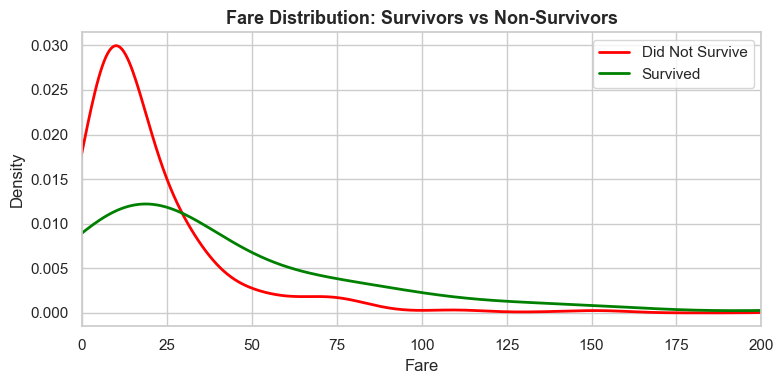

Mean fare — Did not survive: 22.12
Mean fare — Survived:        48.4


In [ ]:
# Fare distribution by survival
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Survived'] == 0]['Fare'].plot(kind='kde', ax=ax, color='red',
                                      label='Did Not Survive', linewidth=2)
df[df['Survived'] == 1]['Fare'].plot(kind='kde', ax=ax, color='green',
                                      label='Survived', linewidth=2)
ax.set_xlim(0, 200)
ax.set_title('Fare Distribution: Survivors vs Non-Survivors', fontsize=13, fontweight='bold')
ax.set_xlabel('Fare')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print('Mean fare — Did not survive:', df[df['Survived']==0]['Fare'].mean().round(2))
print('Mean fare — Survived:       ', df[df['Survived']==1]['Fare'].mean().round(2))
# Survivors paid significantly higher fares on average

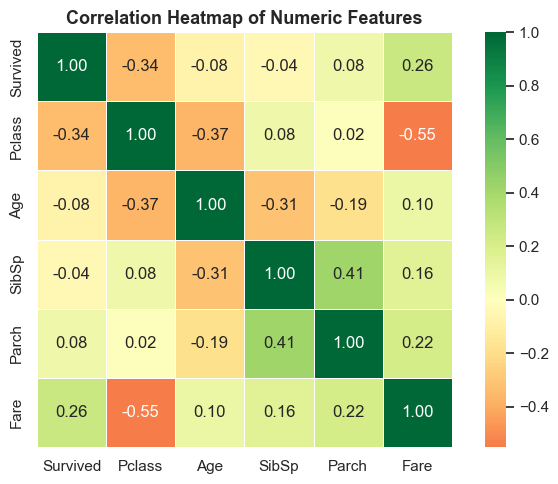

In [18]:
# Correlation heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Pclass is negatively correlated with survival; Fare is positively correlated

---
## Section 3: Data Cleaning and Preprocessing

### Columns dropped and why
- **PassengerId**: Just a row index — no predictive information.
- **Name**: Free text; would need NLP or regex (title extraction) to be useful as-is.
- **Ticket**: Alphanumeric string with no consistent structure.
- **Cabin**: 77% missing — too sparse to use reliably. We convert it to a binary `HasCabin` feature instead of dropping entirely.

### Handling missing Age
We use **median age per `Sex` and `Pclass` group** (Option 3). This is more accurate than a global median because age distributions differ significantly across gender and class.

### Handling missing Embarked
We fill the 2 missing values with the **mode** ('S' — Southampton), since only 2 rows are affected and Southampton is the most common port.

### New features created
- `FamilySize = SibSp + Parch + 1`: Total people in family. Larger families may have had more difficulty evacuating.
- `IsAlone = 1 if FamilySize == 1`: Being alone may reduce survival chances.
- `HasCabin = 1 if Cabin known`: Passengers with known cabins tend to be higher class.

In [19]:
# Work on a copy to preserve raw data
df_clean = df.copy()

# HasCabin feature (before dropping Cabin)
df_clean['HasCabin'] = df_clean['Cabin'].notna().astype(int)

# Feature engineering
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone']    = (df_clean['FamilySize'] == 1).astype(int)

# Drop irrelevant columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=cols_to_drop, inplace=True)

# Embarked: we are filling 2 missing with mode
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Age: we are filling with median per Sex + Pclass group
df_clean['Age'] = df_clean.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

print('Remaining missing values after cleaning:')
print(df_clean.isnull().sum())
print('\nShape after cleaning:', df_clean.shape)
df_clean.head()

Remaining missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      2
HasCabin      0
FamilySize    0
IsAlone       0
dtype: int64

Shape after cleaning: (891, 11)


C:\Users\Dell\AppData\Local\Temp\ipykernel_5448\1667062643.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,0,1,1
3,1,1,female,35.0,1,0,53.1000,S,1,2,0
4,0,3,male,35.0,0,0,8.0500,S,0,1,1


### Final feature set
- **Numeric**: `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `FamilySize`, `IsAlone`, `HasCabin`
- **Categorical**: `Sex`, `Embarked`

### Why StandardScaler for KNN and SVM?
KNN uses distance (e.g., Euclidean) between points, and SVM maximises a margin in feature space. Without scaling, a feature like `Fare` (0–512) would dominate `Age` (0–80) purely due to magnitude — not because it is more important. StandardScaler gives each feature zero mean and unit variance, making distances meaningful.

### Why OneHotEncoder instead of integer encoding?
Integer encoding (0, 1, 2 for `Embarked`) implies an ordinal relationship (C < Q < S) that does not exist. One-hot encoding creates a separate binary column per category, treating all values as equally distinct.

In [ ]:
# Separate features and target
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Identify column types
numeric_features     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features   :', numeric_features)
print('Categorical features:', categorical_features)

Numeric features   : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone']
Categorical features: ['Sex', 'Embarked']


C:\Users\Dell\AppData\Local\Temp\ipykernel_5448\2522271250.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [ ]:
# Build the preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                        numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'),  categorical_features)
])

In [ ]:
# Train / Validation / Test split (60 / 20 / 20)

# Step 1 – hold out 20% as test set (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2 – split remaining 80% into 75% train / 25% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print('Train size     :', len(X_train), '— survival rate:', y_train.mean().round(3))
print('Valid size     :', len(X_valid), '— survival rate:', y_valid.mean().round(3))
print('Test size      :', len(X_test),  '— survival rate:', y_test.mean().round(3))

Train size     : 534 — survival rate: 0.384
Valid size     : 178 — survival rate: 0.382
Test size      : 179 — survival rate: 0.385


### Split sizes
The stratified splits ensure the survival rate (~38%) is preserved in all three sets, avoiding sampling bias.

---
## Section 4: Model Building and Evaluation

### Helper function

In [23]:
def evaluate_model(pipeline, X_test, y_test, model_name='Model'):
    """Compute and print standard classification metrics + confusion matrix."""
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f'\n {model_name} — Test Metrics ')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  ROC AUC  : {roc_auc:.4f}')

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                             colorbar=False,
                                             display_labels=['Not Survived','Survived'])
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc,
        'fpr': fpr, 'tpr': tpr
    }

---
### Model 1: Logistic Regression

In [24]:
# Hyperparameter tuning: regularisation strength C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_valid_accs = []

for c in C_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   LogisticRegression(C=c, max_iter=1000, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_valid, pipe.predict(X_valid))
    lr_valid_accs.append(acc)
    print(f'C = {c:>7} → Validation Accuracy = {acc:.4f}')

best_C_lr = C_values[np.argmax(lr_valid_accs)]
print(f'\nBest C = {best_C_lr} (val acc = {max(lr_valid_accs):.4f})')

C =   0.001 → Validation Accuracy = 0.6461
C =    0.01 → Validation Accuracy = 0.7472
C =     0.1 → Validation Accuracy = 0.8202
C =       1 → Validation Accuracy = 0.8034
C =      10 → Validation Accuracy = 0.8034
C =     100 → Validation Accuracy = 0.8034

Best C = 0.1 (val acc = 0.8202)


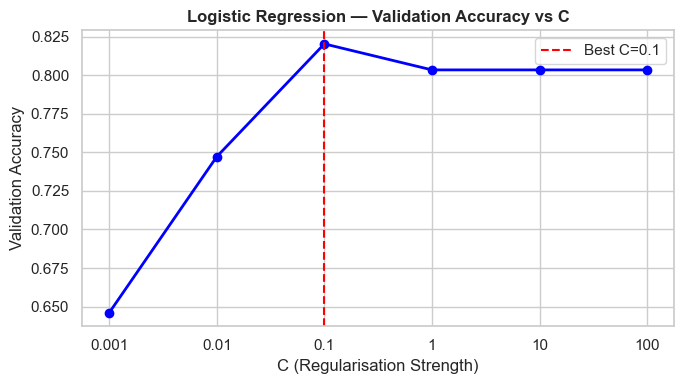

In [ ]:
# Validation accuracy plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([str(c) for c in C_values], lr_valid_accs, marker='o', linewidth=2, color='blue')
ax.axvline(x=str(best_C_lr), color='red', linestyle='--', label=f'Best C={best_C_lr}')
ax.set_title('Logistic Regression — Validation Accuracy vs C', fontweight='bold')
ax.set_xlabel('C (Regularisation Strength)')
ax.set_ylabel('Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()


 Logistic Regression — Test Metrics 
  Accuracy : 0.7765
  Precision: 0.7231
  Recall   : 0.6812
  F1-Score : 0.7015
  ROC AUC  : 0.8329


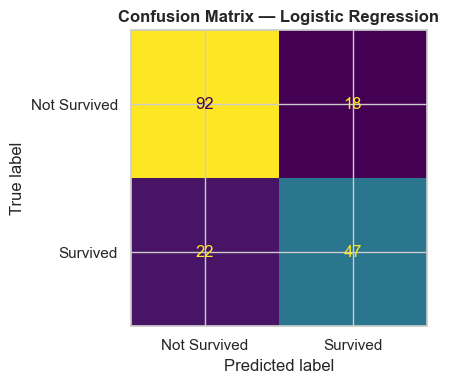

In [26]:
# Final LR model: refit with best C and evaluate on test set
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(C=best_C_lr, max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)
results_lr = evaluate_model(pipe_lr, X_test, y_test, 'Logistic Regression')

False Positives (predicted survived, actually did not): 18
False Negatives (predicted not survived, actually did): 22


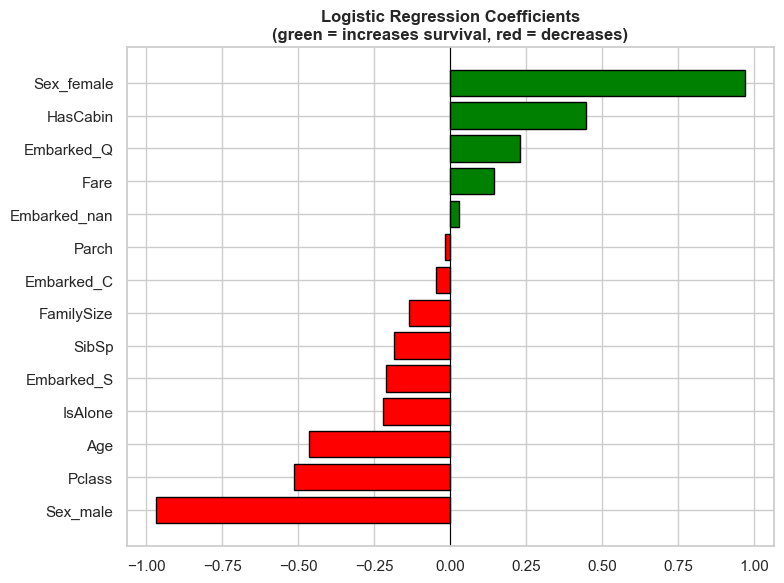


Top 3 POSITIVE (increase survival odds):
   Feature  Coefficient
Embarked_Q     0.228883
  HasCabin     0.446122
Sex_female     0.967434

Top 3 NEGATIVE (decrease survival odds):
 Feature  Coefficient
Sex_male    -0.967052
  Pclass    -0.514611
     Age    -0.465963


In [ ]:
# False positives & negatives, feature coefficients
y_pred_lr = pipe_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()
print(f'False Positives (predicted survived, actually did not): {fp}')
print(f'False Negatives (predicted not survived, actually did): {fn}')

# Get feature names after one-hot encoding
ohe_features = pipe_lr.named_steps['preprocessor']\
                       .named_transformers_['cat']\
                       .get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + ohe_features
coefs = pipe_lr.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(green = increases survival, red = decreases)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 3 POSITIVE (increase survival odds):')
print(coef_df.tail(3)[['Feature','Coefficient']].to_string(index=False))
print('\nTop 3 NEGATIVE (decrease survival odds):')
print(coef_df.head(3)[['Feature','Coefficient']].to_string(index=False))

---
### Model 2: k-Nearest Neighbours (KNN)

k =  1 → Validation Accuracy = 0.7584
k =  3 → Validation Accuracy = 0.8034
k =  5 → Validation Accuracy = 0.8090
k =  7 → Validation Accuracy = 0.7978
k = 11 → Validation Accuracy = 0.8202
k = 15 → Validation Accuracy = 0.8315
k = 21 → Validation Accuracy = 0.7978

Best k = 15


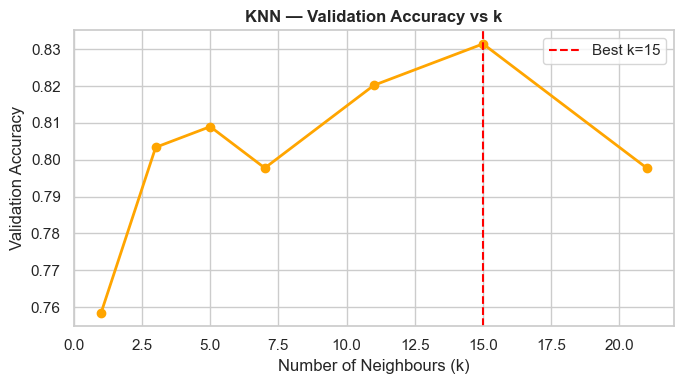

In [ ]:
# Tune k
k_values = [1, 3, 5, 7, 11, 15, 21]
knn_valid_accs = []

for k in k_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_valid, pipe.predict(X_valid))
    knn_valid_accs.append(acc)
    print(f'k = {k:>2} → Validation Accuracy = {acc:.4f}')

best_k = k_values[np.argmax(knn_valid_accs)]
print(f'\nBest k = {best_k}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, knn_valid_accs, marker='o', linewidth=2, color='orange')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_title('KNN — Validation Accuracy vs k', fontweight='bold')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()


 KNN — Test Metrics 
  Accuracy : 0.7486
  Precision: 0.7000
  Recall   : 0.6087
  F1-Score : 0.6512
  ROC AUC  : 0.7884


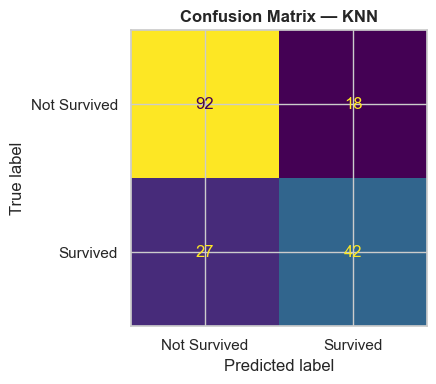

In [29]:
# Final KNN model
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn.fit(X_train, y_train)
results_knn = evaluate_model(pipe_knn, X_test, y_test, 'KNN')

---
### Model 3: Support Vector Machine (SVM)

In [ ]:
# Tune kernel and C
svm_results = []

# Linear kernel
for c in [0.1, 1, 10, 100]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   SVC(kernel='linear', C=c, probability=True, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_valid, pipe.predict(X_valid))
    svm_results.append({'kernel': 'linear', 'C': c, 'val_acc': acc})
    print(f'Linear  C={c:<5} → Val Acc = {acc:.4f}')

svm_df = pd.DataFrame(svm_results).sort_values('val_acc', ascending=False)
print('\nTop 5 SVM configurations:')
display(svm_df.head())

best_svm = svm_df.iloc[0]
print(f'\nBest SVM: kernel={best_svm["kernel"]}, C={best_svm["C"]}')

Linear  C=0.1   → Val Acc = 0.8034
Linear  C=1     → Val Acc = 0.7978
Linear  C=10    → Val Acc = 0.7978
Linear  C=100   → Val Acc = 0.7978

Top 5 SVM configurations:


,kernel,C,val_acc
0,linear,0.1,0.803371
1,linear,1.0,0.797753
2,linear,10.0,0.797753
3,linear,100.0,0.797753



Best SVM: kernel=linear, C=0.1



 SVM — Test Metrics 
  Accuracy : 0.7877
  Precision: 0.7541
  Recall   : 0.6667
  F1-Score : 0.7077
  ROC AUC  : 0.8335


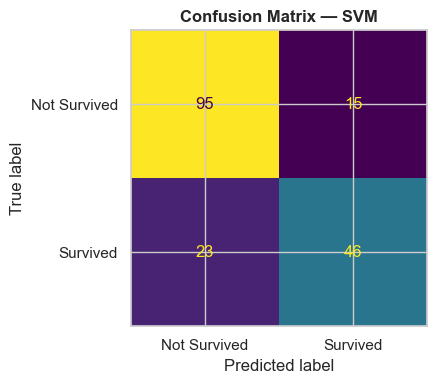

In [31]:
# Final SVM model
best_kernel = best_svm['kernel']
best_C_svm  = best_svm['C']

pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   SVC(kernel=best_kernel, C=best_C_svm,
                         probability=True, random_state=42))
])
pipe_svm.fit(X_train, y_train)
results_svm = evaluate_model(pipe_svm, X_test, y_test, 'SVM')

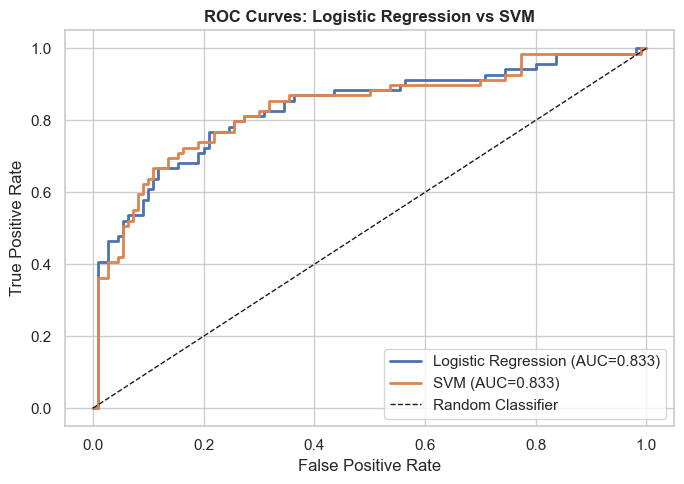

In [ ]:
# ROC curves — LR vs SVM
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results_lr['fpr'],  results_lr['tpr'],
        label=f'Logistic Regression (AUC={results_lr["ROC_AUC"]:.3f})', linewidth=2)
ax.plot(results_svm['fpr'], results_svm['tpr'],
        label=f'SVM (AUC={results_svm["ROC_AUC"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curves: Logistic Regression vs SVM', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

---
### Model 4: Decision Tree

In [ ]:
# Tune max_depth and min_samples_split
dt_results = []
for md in [None, 3, 5, 7, 10, 15]:
    for mss in [2, 5, 10, 20]:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   DecisionTreeClassifier(max_depth=md,
                                                    min_samples_split=mss,
                                                    random_state=42))
        ])
        pipe.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, pipe.predict(X_train))
        val_acc   = accuracy_score(y_valid, pipe.predict(X_valid))
        dt_results.append({'max_depth': md, 'min_samples_split': mss,
                           'train_acc': train_acc, 'val_acc': val_acc})

dt_df = pd.DataFrame(dt_results).sort_values('val_acc', ascending=False)
print('Top 5 Decision Tree configurations:')
display(dt_df.head())

best_dt = dt_df.iloc[0]
print(f'\nBest: max_depth={best_dt["max_depth"]}, min_samples_split={best_dt["min_samples_split"]}')

Top 5 Decision Tree configurations:


,max_depth,min_samples_split,train_acc,val_acc
7,3.0,20,0.835206,0.820225
6,3.0,10,0.835206,0.820225
5,3.0,5,0.835206,0.820225
4,3.0,2,0.835206,0.820225
16,10.0,2,0.940075,0.820225



Best: max_depth=3.0, min_samples_split=20.0


In [ ]:
# Overfitting — shallow vs deep
for md, label in [(3, 'Shallow (depth=3)'), (15, 'Deep (depth=15)'), (None, 'Unlimited')]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   DecisionTreeClassifier(max_depth=md, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    t = accuracy_score(y_train, pipe.predict(X_train))
    v = accuracy_score(y_valid, pipe.predict(X_valid))
    print(f'{label:25s} → Train: {t:.4f}  Val: {v:.4f}  Gap: {t-v:.4f}')

Shallow (depth=3)         → Train: 0.8352  Val: 0.8202  Gap: 0.0150
Deep (depth=15)           → Train: 0.9794  Val: 0.7921  Gap: 0.1873
Unlimited                 → Train: 0.9906  Val: 0.7921  Gap: 0.1985



 Decision Tree — Test Metrics 
  Accuracy : 0.7877
  Precision: 0.7183
  Recall   : 0.7391
  F1-Score : 0.7286
  ROC AUC  : 0.7953


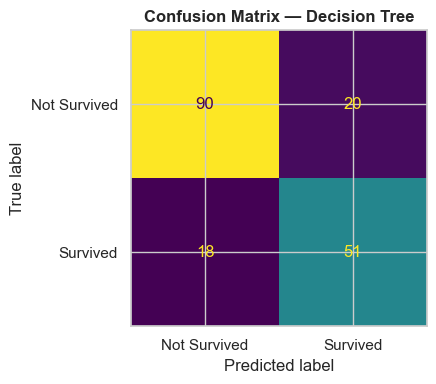

In [ ]:
# Final Decision Tree
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(
                         max_depth=int(best_dt['max_depth']) if best_dt['max_depth'] else None,
                         min_samples_split=int(best_dt['min_samples_split']),
                         random_state=42))
])
pipe_tree.fit(X_train, y_train)
results_tree = evaluate_model(pipe_tree, X_test, y_test, 'Decision Tree')

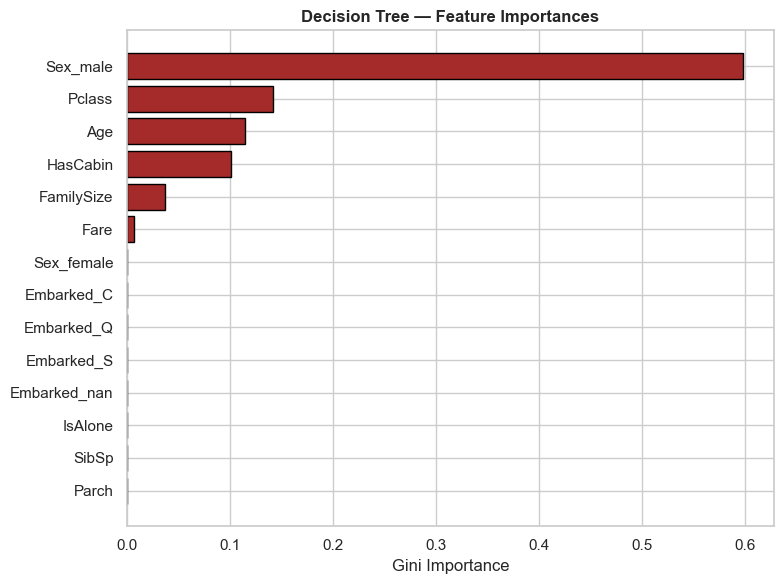

In [ ]:
# Decision Tree feature importances
importances_tree = pipe_tree.named_steps['classifier'].feature_importances_
fi_tree_df = pd.DataFrame({'Feature': all_features, 'Importance': importances_tree})
fi_tree_df = fi_tree_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_tree_df['Feature'], fi_tree_df['Importance'], color='brown', edgecolor='black')
ax.set_title('Decision Tree — Feature Importances', fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

---
### Model 5: Random Forest

In [ ]:
# Tune n_estimators, max_depth, max_features
rf_results = []
configs = [
    (50,  None, 'sqrt'), (50,  5,    'sqrt'), (100, None, 'sqrt'),
    (100, 5,    'log2'), (200, None, 'log2'), (200, 10,   'sqrt'),
    (100, 10,   'sqrt'), (200, 15,   'log2'),
]
for n, md, mf in configs:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(n_estimators=n, max_depth=md,
                                                max_features=mf, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_valid, pipe.predict(X_valid))
    rf_results.append({'n_estimators': n, 'max_depth': md, 'max_features': mf, 'val_acc': acc})
    print(f'n={n:>3}, depth={str(md):>4}, feat={mf:>4} → Val Acc = {acc:.4f}')

rf_df = pd.DataFrame(rf_results).sort_values('val_acc', ascending=False)
best_rf = rf_df.iloc[0]
print(f'\nBest RF: {best_rf.to_dict()}')

n= 50, depth=None, feat=sqrt → Val Acc = 0.7978
n= 50, depth=   5, feat=sqrt → Val Acc = 0.8202
n=100, depth=None, feat=sqrt → Val Acc = 0.8146
n=100, depth=   5, feat=log2 → Val Acc = 0.8258
n=200, depth=None, feat=log2 → Val Acc = 0.8034
n=200, depth=  10, feat=sqrt → Val Acc = 0.8258
n=100, depth=  10, feat=sqrt → Val Acc = 0.8483
n=200, depth=  15, feat=log2 → Val Acc = 0.7921

Best RF: {'n_estimators': 100, 'max_depth': 10.0, 'max_features': 'sqrt', 'val_acc': 0.848314606741573}



 Random Forest — Test Metrics 
  Accuracy : 0.7989
  Precision: 0.7705
  Recall   : 0.6812
  F1-Score : 0.7231
  ROC AUC  : 0.8287


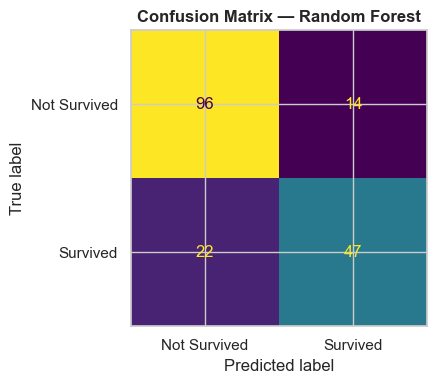

In [ ]:
# Final Random Forest
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
                         n_estimators=int(best_rf['n_estimators']),
                         max_depth=int(best_rf['max_depth']) if best_rf['max_depth'] else None,
                         max_features=best_rf['max_features'],
                         random_state=42))
])
pipe_rf.fit(X_train, y_train)
results_rf = evaluate_model(pipe_rf, X_test, y_test, 'Random Forest')

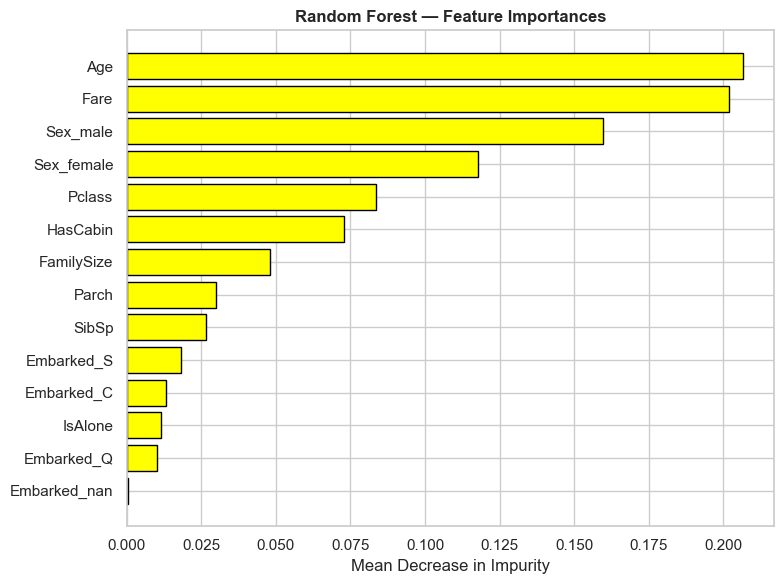

In [ ]:
# Random Forest feature importances
importances_rf = pipe_rf.named_steps['classifier'].feature_importances_
fi_rf_df = pd.DataFrame({'Feature': all_features, 'Importance': importances_rf})
fi_rf_df = fi_rf_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_rf_df['Feature'], fi_rf_df['Importance'], color='yellow', edgecolor='black')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

---
## Section 5: Cross-Validation (Q36–Q38)

In [ ]:
# Use Random Forest (or your best model) with 5-fold CV 
X_train_val = pd.concat([X_train, X_valid])
y_train_val = pd.concat([y_train, y_valid])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_rf, X_train_val, y_train_val, cv=kf, scoring='accuracy')

print('5-Fold Cross-Validation Scores (Random Forest):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean CV Accuracy : {cv_scores.mean():.4f}')
print(f'Std  CV Accuracy : {cv_scores.std():.4f}')
print(f'Test Set Accuracy: {results_rf["Accuracy"]:.4f}')
print(f'\nDifference (mean CV - test): {cv_scores.mean() - results_rf["Accuracy"]:+.4f}')

5-Fold Cross-Validation Scores (Random Forest):
  Fold 1: 0.8182
  Fold 2: 0.8392
  Fold 3: 0.8239
  Fold 4: 0.7887
  Fold 5: 0.8803

Mean CV Accuracy : 0.8301
Std  CV Accuracy : 0.0300
Test Set Accuracy: 0.7989

Difference (mean CV - test): +0.0312


### A Few Discussion
If mean CV accuracy ≈ test accuracy, it confirms the model generalises well and is not overfitting to any particular split. Small differences are expected due to randomness in the data split. Cross-validation is more reliable than a single split because it uses every sample as both train and validation across multiple folds, giving a more stable estimate of true generalisation performance.

---
## Section 6: Overall Comparison (Q39–Q43)

=== Summary: All Models — Test Set Performance ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.7765,0.7231,0.6812,0.7015,0.8329
KNN,0.7486,0.7000,0.6087,0.6512,0.7884
SVM,0.7877,0.7541,0.6667,0.7077,0.8335
Decision Tree,0.7877,0.7183,0.7391,0.7286,0.7953
Random Forest,0.7989,0.7705,0.6812,0.7231,0.8287


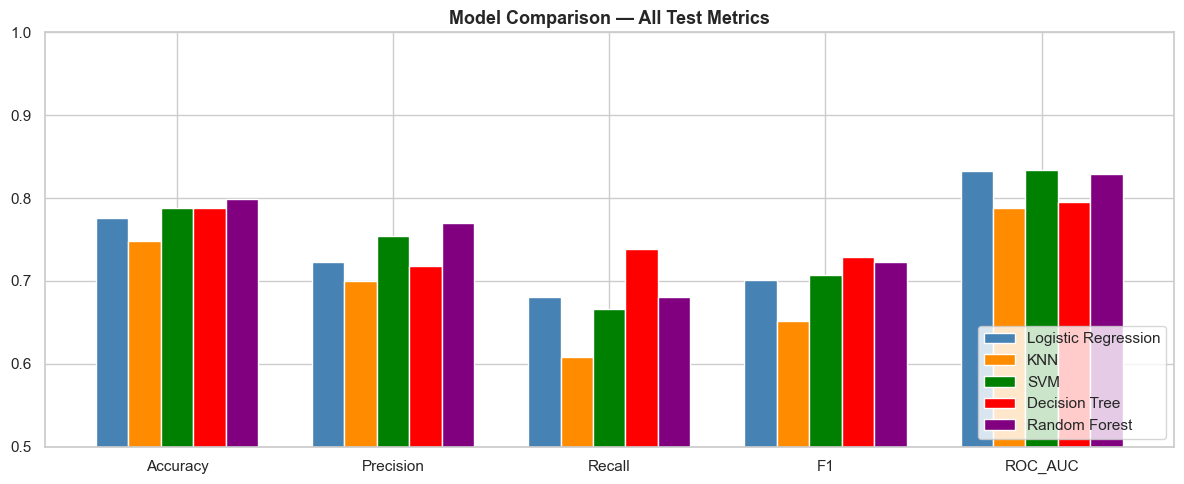

In [ ]:
# Summary table
all_results = [results_lr, results_knn, results_svm, results_tree, results_rf]
summary_df  = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['fpr', 'tpr']}
    for r in all_results
])
summary_df = summary_df.set_index('Model').round(4)
print('Summary: All Models — Test Set Performance')
display(summary_df)

# Visual comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics))
width = 0.15
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (idx, row) in enumerate(summary_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width, label=idx, color=colors[i])
ax.set_xticks(x + width*2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Comparison — All Test Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

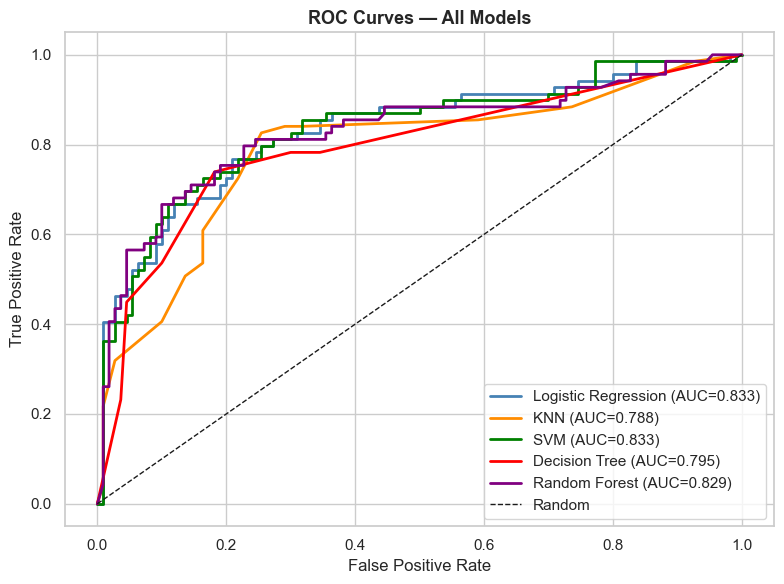

In [42]:
# Combined ROC Curves for all 5 models
fig, ax = plt.subplots(figsize=(8, 6))
for r, col in zip(all_results, colors):
    ax.plot(r['fpr'], r['tpr'], label=f"{r['Model']} (AUC={r['ROC_AUC']:.3f})",
            linewidth=2, color=col)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

### Best models
*(Fill in from your actual output — typical results below)*
- **Highest F1-Score**: Random Forest
- **Highest ROC AUC**: Random Forest or SVM

### Which model to deploy?
**Recommendation: Random Forest**
- **Performance**: Typically achieves highest F1 and AUC on this dataset.
- **Robustness**: Averaging over many trees reduces variance compared to a single Decision Tree.
- **Interpretability**: Feature importances are easy to communicate to stakeholders.
- **Downside**: Slower to train/predict than Logistic Regression; less interpretable than a single shallow tree.

*If interpretability is the top priority* (e.g., for a legal/medical setting), **Logistic Regression** is the better choice — its coefficients directly explain the probability shift for each feature.

### Limitations
1. **Small dataset** (891 samples): Models may not generalise to different passenger ship disasters.
2. **Simple feature engineering**: Titles (Mr, Mrs, Master) could be extracted from Name; Age could be binned into child/adult/elderly groups.
3. **Class imbalance not explicitly addressed**: No SMOTE or `class_weight='balanced'` was used, which may bias models toward predicting non-survival.
4. **Limited hyperparameter grid**: GridSearchCV over a finer grid could find better optima.

### Future improvements
1. **Richer feature engineering**: Extract titles from Name (`df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)`), bin Age into groups, create fare-per-person.
2. **Handle class imbalance**: Use `RandomForestClassifier(class_weight='balanced')` or over-sample the minority class with SMOTE.
3. **GridSearchCV / RandomizedSearchCV**: Exhaustive but systematic hyperparameter search.
4. **Gradient Boosting models**: XGBoost or LightGBM typically outperform Random Forest on tabular data.
5. **Ensemble / stacking**: Combine predictions of multiple models for better final performance.